最大化动作的熵,增强模型的稳定性

Q(state,action) + alpha * 熵\[Q(static,*)\]

训练过程中alpha应该递减.

为了缓解自举,会用两个value模型评估Q函数,取其中小的值.

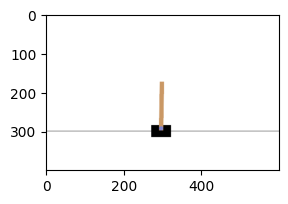

In [1]:
import gym


#定义环境
class MyWrapper(gym.Wrapper):

    def __init__(self):
        env = gym.make('CartPole-v1', render_mode='rgb_array')
        super().__init__(env)
        self.env = env
        self.step_n = 0

    def reset(self):
        state, _ = self.env.reset()
        self.step_n = 0
        return state

    def step(self, action):
        state, reward, terminated, truncated, info = self.env.step(action)
        over = terminated or truncated

        #限制最大步数
        self.step_n += 1
        if self.step_n >= 200:
            over = True

        return state, reward, over

    #打印游戏图像
    def show(self):
        from matplotlib import pyplot as plt
        plt.figure(figsize=(3, 3))
        plt.imshow(self.env.render())
        plt.show()


env = MyWrapper()

env.reset()

env.show()

In [2]:
import torch

model_action = torch.nn.Sequential(
    torch.nn.Linear(4, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 2),
    torch.nn.Softmax(dim=1),
)

model_action(torch.randn(2, 4))

/root/miniconda3/envs/pt39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor([[0.4432, 0.5568],
        [0.4667, 0.5333]], grad_fn=<SoftmaxBackward0>)

In [3]:
model_value1 = torch.nn.Sequential(
    torch.nn.Linear(4, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 2),
)

model_value2 = torch.nn.Sequential(
    torch.nn.Linear(4, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 2),
)

model_value1_next = torch.nn.Sequential(
    torch.nn.Linear(4, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 2),
)

model_value2_next = torch.nn.Sequential(
    torch.nn.Linear(4, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 2),
)

model_value1_next.load_state_dict(model_value1.state_dict())
model_value2_next.load_state_dict(model_value2.state_dict())

model_value1(torch.randn(2, 4))

tensor([[-0.1202,  0.0161],
        [-0.1651,  0.0571]], grad_fn=<AddmmBackward0>)

In [4]:
from IPython import display
import random


#玩一局游戏并记录数据
def play(show=False):
    data = []
    reward_sum = 0

    state = env.reset()
    over = False
    while not over:
        prob = model_action(torch.FloatTensor(state).reshape(1, 4))[0].tolist()
        action = random.choices(range(2), weights=prob, k=1)[0]

        next_state, reward, over = env.step(action)

        data.append((state, action, reward, next_state, over))
        reward_sum += reward

        state = next_state

        if show:
            display.clear_output(wait=True)
            env.show()

    return data, reward_sum


play()[-1]

/root/miniconda3/envs/pt39/lib/python3.9/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


41.0

In [5]:
#数据池
class Pool:

    def __init__(self):
        self.pool = []

    def __len__(self):
        return len(self.pool)

    def __getitem__(self, i):
        return self.pool[i]

    #更新动作池
    def update(self):
        #每次更新不少于N条新数据
        old_len = len(self.pool)
        while len(pool) - old_len < 200:
            self.pool.extend(play()[0])

        #只保留最新的N条数据
        self.pool = self.pool[-2_0000:]

    #获取一批数据样本
    def sample(self):
        data = random.sample(self.pool, 64)

        state = torch.FloatTensor([i[0] for i in data]).reshape(-1, 4)
        action = torch.LongTensor([i[1] for i in data]).reshape(-1, 1)
        reward = torch.FloatTensor([i[2] for i in data]).reshape(-1, 1)
        next_state = torch.FloatTensor([i[3] for i in data]).reshape(-1, 4)
        over = torch.LongTensor([i[4] for i in data]).reshape(-1, 1)

        return state, action, reward, next_state, over


pool = Pool()
pool.update()
state, action, reward, next_state, over = pool.sample()

len(pool), pool[0]

/tmp/ipykernel_3862/3891364554.py:27: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  ../torch/csrc/utils/tensor_new.cpp:201.)
  state = torch.FloatTensor([i[0] for i in data]).reshape(-1, 4)


(208,
 (array([-0.01133511,  0.02609218, -0.04308971,  0.03115952], dtype=float32),
  1,
  1.0,
  array([-0.01081327,  0.22180472, -0.04246651, -0.27480125], dtype=float32),
  False))

In [6]:
optimizer_action = torch.optim.Adam(model_action.parameters(), lr=2e-4)
optimizer_value1 = torch.optim.Adam(model_value1.parameters(), lr=2e-3)
optimizer_value2 = torch.optim.Adam(model_value2.parameters(), lr=2e-3)


def soft_update(_from, _to):
    for _from, _to in zip(_from.parameters(), _to.parameters()):
        value = _to.data * 0.995 + _from.data * 0.005
        _to.data.copy_(value)


def get_prob_entropy(state):
    prob = model_action(torch.FloatTensor(state).reshape(-1, 4))
    entropy = prob * (prob + 1e-8).log()
    entropy = -entropy.sum(dim=1, keepdim=True)

    return prob, entropy


def requires_grad(model, value):
    for param in model.parameters():
        param.requires_grad_(value)


alpha = 1.0

In [7]:
def train_value(state, action, reward, next_state, over):
    requires_grad(model_value1, True)
    requires_grad(model_value2, True)
    requires_grad(model_action, False)

    #计算target
    with torch.no_grad():
        #计算动作的熵
        prob, entropy = get_prob_entropy(next_state)
        target1 = model_value1_next(next_state)
        target2 = model_value2_next(next_state)
        target = torch.min(target1, target2)

    target = (prob * target).sum(dim=1, keepdim=True)
    target = target * 0.98 * (1 - over) + reward

    #计算value
    value = model_value1(state).gather(dim=1, index=action)
    loss = torch.nn.functional.mse_loss(value, target)
    loss.backward()
    optimizer_value1.step()
    optimizer_value1.zero_grad()

    value = model_value2(state).gather(dim=1, index=action)
    loss = torch.nn.functional.mse_loss(value, target)
    loss.backward()
    optimizer_value2.step()
    optimizer_value2.zero_grad()

    return loss.item()


train_value(state, action, reward, next_state, over)

0.8865742683410645

In [8]:
def train_action(state):
    requires_grad(model_value1, False)
    requires_grad(model_value2, False)
    requires_grad(model_action, True)

    #计算熵
    prob, entropy = get_prob_entropy(state)

    #计算value
    value1 = model_value1(state)
    value2 = model_value2(state)
    value = torch.min(value1, value2)

    #求期望求和
    value = (prob * value).sum(dim=1, keepdim=True)

    #加权熵
    loss = -(value + alpha * entropy).mean()

    loss.backward()
    optimizer_action.step()
    optimizer_action.zero_grad()

    return loss.item(), value.mean().item(), entropy.mean().item()


train_action(state)

(-0.6628562211990356, -0.029635075479745865, 0.6924912929534912)

In [9]:
def train():
    global alpha
    model_action.train()
    model_value1.train()
    model_value2.train()

    #训练N次
    for epoch in range(400):
        #更新N条数据
        pool.update()

        #每次更新过数据后,学习N次
        for i in range(200):
            #采样一批数据
            state, action, reward, next_state, over = pool.sample()

            #训练
            train_value(state, action, reward, next_state, over)
            loss, value, entropy = train_action(state)
            soft_update(model_value1, model_value1_next)
            soft_update(model_value2, model_value2_next)

        alpha *= 0.9
        if alpha < 0.01:
            alpha = 0.01

        if epoch % 20 == 0:
            test_result = sum([play()[-1] for _ in range(20)]) / 20
            print(epoch, len(pool), value, entropy, alpha, test_result)


train()

0 422 1.5122120380401611 0.6929896473884583 0.9 22.8
20 5398 16.651247024536133 0.3631843328475952 0.10941898913151243 186.15
40 9570 25.803791046142578 0.3006227910518646 0.013302794647291147 200.0
60 13748 30.822830200195312 0.18675236403942108 0.01 200.0
80 17908 32.093055725097656 0.23819035291671753 0.01 200.0
100 20000 37.02988052368164 0.1701749712228775 0.01 200.0
120 20000 35.0540657043457 0.14277850091457367 0.01 200.0
140 20000 33.96101379394531 0.10680395364761353 0.01 200.0
160 20000 35.81119918823242 0.11964555084705353 0.01 200.0
180 20000 37.465599060058594 0.1735144555568695 0.01 200.0
200 20000 36.46296691894531 0.15052780508995056 0.01 157.65
220 20000 34.97403335571289 0.14578697085380554 0.01 116.15
240 20000 33.448204040527344 0.07098975777626038 0.01 196.75
260 20000 34.299198150634766 0.12434455752372742 0.01 154.9
280 20000 35.75654602050781 0.09406730532646179 0.01 198.85
300 20000 35.23383331298828 0.06821824610233307 0.01 200.0
320 20000 35.43982696533203 0.

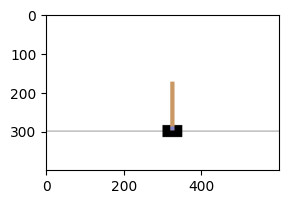

200.0

In [10]:
play(True)[-1]